The following is my simulation of mRNA movements and binding around the mitochondrion. I decided to represent this system as a directional graph, and coded some functions that mean it should theoretically be able to run for any graph, meaning this could be expanded to the other examples if necessary. The model seems to run correctly, as testing it on the simplest graphs possible for which the steady state was well understood yielded almost exactly the predicted result.

Throughout this code, I referred to mRNA as just "particles" for convenience.

I begin by importing the various modules I used or may use here, including two custom modules I created - one for the directional graph object and one for simulation function that currently contains a function to move one timestep forward. 

The directional graph object has two components: "Edges", which is a list of lists of the form [starting_node, ending_node, weight] (weight in our case being the rate of transfer) and "Nodes", which is just a node count for easy reference and future use. 

In [1]:
# Import Modules

import matplotlib.pyplot as plot
import numpy as np
import random
import math
from dgraph_object import *
from simulation_functions import *



We define the graph below: every edge should be included here, and the missing each centrally the top row is in fact removed. I used a 10*2 grid. 

Particle positions are also defined here, as a list where each index is a particle and the number stored their the node the particle is on. This means that if we wish, we can track an individual particle's journey. Currently, all particles start at the top left corner (binding and as far as possible into the mitochondria).

In [2]:


# Define the Graph
KBC = 1
KNBC = 1
KD = 2
example_weighted_dgraph = dGraph(edges=[[0,1,KD],[1,0,KD],[2,1,KD],[1,2,KD],[2,3,KD],[3,2,KD],[4,3,KD],[3,4,KD],[5,4,KD],[5,6,KD],[6,5,KD],[6,7,KD],[7,6,KD],[8,7,KD],[7,8,KD],[8,9,KD],[9,8,KD],[10,11,KD],[11,10,KD],[12,11,KD],[11,12,KD],[12,13,KD],[13,12,KD],[13,14,KD],[14,13,KD],[14,15,KD],[15,14,KD],[15,16,KD],[16,15,KD],[16,17,KD],[17,16,KD],[17,18,KD],[18,17,KD],[18,19,KD],[19,18,KD],[0,10,KNBC],[10,0,KBC],[1,11,KNBC],[11,1,KBC],[2,12,KNBC],[12,2,KBC],[3,13,KNBC],[13,3,KBC],[4,14,KNBC],[14,4,KBC],[5,15,KNBC],[15,5,KBC],[6,16,KNBC],[16,6,KBC],[7,17,KNBC],[17,7,KBC],[8,18,KNBC],[18,8,KBC],[9,19,KNBC],[19,9,KBC]],nodes=20,transfers_from = [],transfers_to = [])
transfers_from_nodes(example_weighted_dgraph)
transfers_to_nodes(example_weighted_dgraph)

example_particle_positions = []
particle_count = 1000
for i in range(particle_count):
    example_particle_positions.append(0)



Using our time-step function in the simulation_functions module, we run the simulation to see how particles disperse over time. The values plotted here are specifically the number of non-binding particles inside the mitochondrion, and the number of non_binding particles outside of it. 

The x-axis here is time in an unspecified unit (I have KD set to a rate of 2 transfers per unit) and the y-axis is number of particles.

This generally takes a minute or two to run.

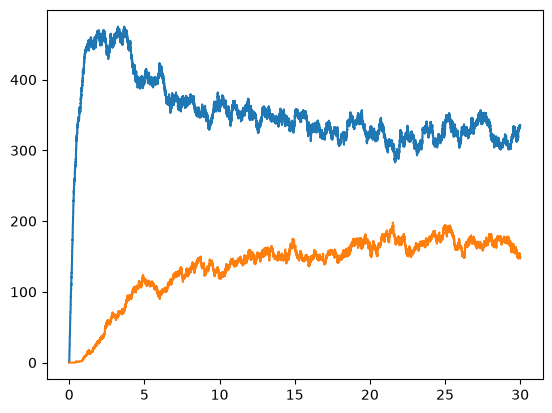

In [3]:


# Run the simulation and plot relative particle concentrations in the binding region
number_non_binding = 0
times = []
quantitiesA = []
quantitiesB = []
y_list = []
time = 0
dt = 0.0001
particle_list_memory = []

#Run through our small timestep 300000 times, each time storing the amount of particles in each of the respective regions. 
for i in range(300000):
    example_particle_positions = one_step(example_weighted_dgraph,example_particle_positions, dt)
    number_non_binding_left = example_particle_positions.count(10)+example_particle_positions.count(11)+example_particle_positions.count(12)+example_particle_positions.count(13)+example_particle_positions.count(14)
    number_non_binding_right = example_particle_positions.count(15)+example_particle_positions.count(16)+example_particle_positions.count(17)+example_particle_positions.count(18)+example_particle_positions.count(19)
    time = time+dt
    times.append(time)
    quantitiesA.append(number_non_binding_left)
    quantitiesB.append(number_non_binding_right)
    #Near the end, every thousand timesteps or so, save the particle positions. We'll average this out later.
    if i>280000 and i % 1000 == 0:
        particle_list_memory.append(example_particle_positions)

#Plot the respective positions.
fig, ax = plot.subplots()
ax.plot(times,quantitiesA)
ax.plot(times,quantitiesB)
plot.show()



Finally, we average out the particle counts near the end, once it's reached a steady state (to help clear out random noise). We can then plot the average number of particles across the 10 squares of the bottom row (the non-binding region). 

The x-axis represents position along the bottom row (with the mitochondrion being on the left) while the y-axis is the percentage of particles in the bottom row in that specific position.

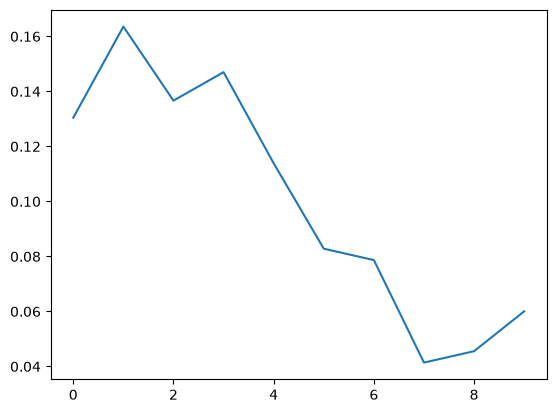

In [4]:
# Plot mRNA concentration relative to position in space

# Convert our raw memory into an array of particle counts in each x position, for future use.
particle_count_array = []
for i in particle_list_memory:
    sub_particle_count = []
    for j in range(10,20):
        sub_particle_count.append(i.count(j))
    particle_count_array.append(sub_particle_count)

# Average the particle counts over time.
average_particle_count = []
for i in range(0,10):
    sum = 0
    for j in range(len(particle_count_array)):
        sum += particle_count_array[j][i]
    avg = sum/len(particle_count_array)
    average_particle_count.append(avg)

# Plot the results.
total_particle_count = 0
for i in average_particle_count:
    total_particle_count += i
positions = []
fractions = []
for i in range(10,20):
    positions.append(i-10)
    fractions.append(average_particle_count[i-10]/total_particle_count)

plot.plot(positions, fractions)